In [ ]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub underthesea

In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-14 09:05:48.089644: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778749548.314455      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778749548.380110      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778749548.909731      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778749548.909774      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778749548.909777      22 computation_placer.cc:177] computation placer alr

In [3]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# B0 baseline singletask 

In [ ]:
# config
MODEL_NAME = "uitnlp/visobert"
MAX_LEN      = 128
BATCH_SIZE   = 32
LR           = 2e-5
EPOCHS       = 10
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]

print(f"Device: {DEVICE}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }


def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        df["sentence"].tolist(),
        # df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device: cuda


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
         # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


B0 (CE): Single Task - Standard Cross Entropy


pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.4931 | Val Loss: 0.2924 | Train F1: 0.5839 | Val F1: 0.7181
New best (Val F1: 0.7181)
Epoch 02 | Train Loss: 0.2579 | Val Loss: 0.2439 | Train F1: 0.7569 | Val F1: 0.7710
New best (Val F1: 0.7710)
Epoch 03 | Train Loss: 0.1647 | Val Loss: 0.2844 | Train F1: 0.8450 | Val F1: 0.7690
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.1110 | Val Loss: 0.3196 | Train F1: 0.9066 | Val F1: 0.8085
New best (Val F1: 0.8085)
Epoch 05 | Train Loss: 0.0741 | Val Loss: 0.3844 | Train F1: 0.9374 | Val F1: 0.7995
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0437 | Val Loss: 0.4776 | Train F1: 0.9636 | Val F1: 0.7854
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0271 | Val Loss: 0.5344 | Train F1: 0.9780 | Val F1: 0.7996
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation sentiment Macro F1: 0.8085


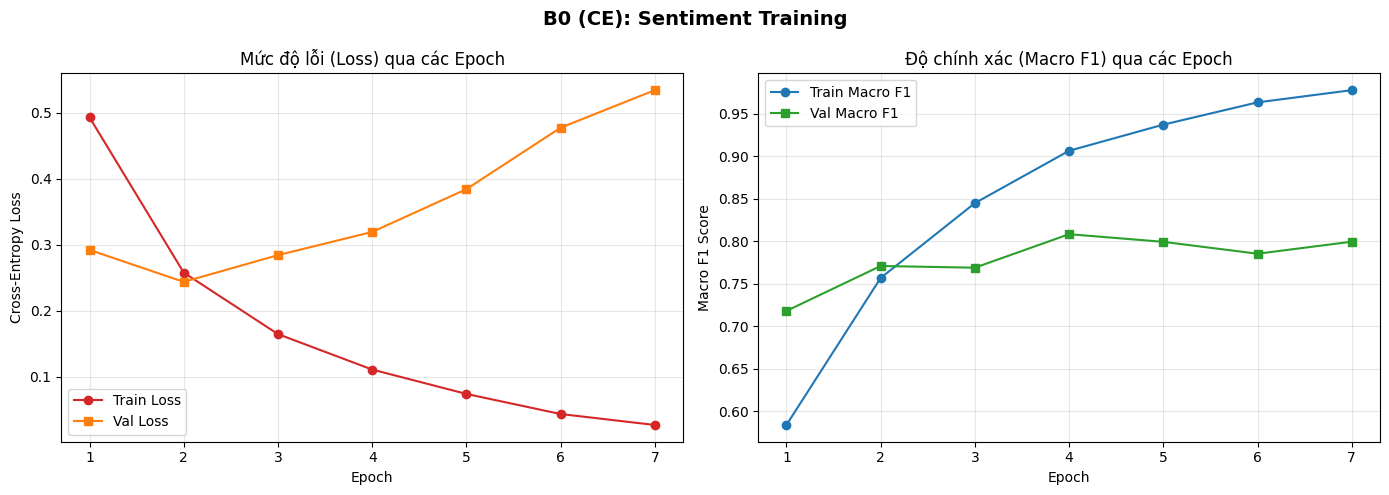


Chẩn đoán validation === B0_CE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9025    0.9716    0.9358       705
     Neutral     0.6481    0.4795    0.5512        73
    Positive     0.9597    0.9180    0.9384       805

    accuracy                         0.9217      1583
   macro avg     0.8368    0.7897    0.8085      1583
weighted avg     0.9199    0.9217    0.9194      1583


=== B0 (CE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.8647    0.9709    0.9147      1409
     Neutral     0.5882    0.3593    0.4461       167
    Positive     0.9555    0.8906    0.9219      1590

    accuracy                         0.8983      3166
   macro avg     0.8028    0.7402    0.7609      3166
weighted avg     0.8957    0.8983    0.8936      3166



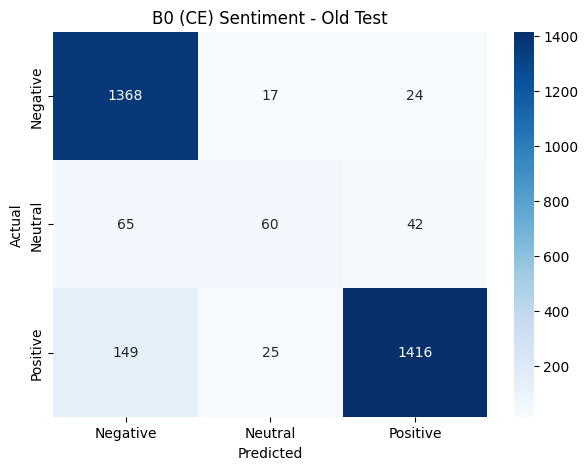


=== B0 (CE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.8673    0.9786    0.9196      1402
     Neutral     0.6078    0.3924    0.4769       158
    Positive     0.9744    0.8991    0.9352      1606

    accuracy                         0.9090      3166
   macro avg     0.8165    0.7567    0.7772      3166
weighted avg     0.9086    0.9090    0.9054      3166



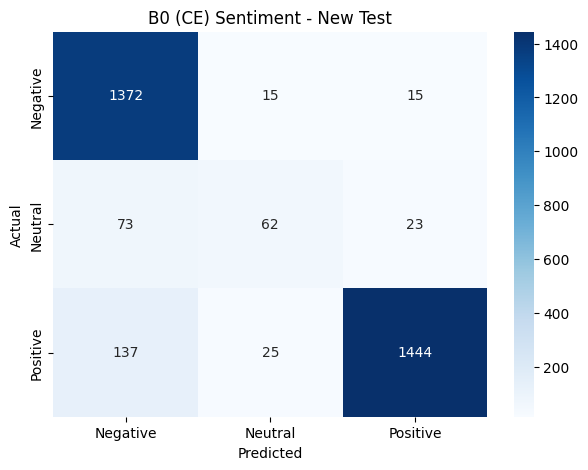

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.5702 | Val Loss: 0.3831 | Train F1: 0.5404 | Val F1: 0.6979
New best (Val F1: 0.6979)
Epoch 02 | Train Loss: 0.3423 | Val Loss: 0.3324 | Train F1: 0.7591 | Val F1: 0.7497
New best (Val F1: 0.7497)
Epoch 03 | Train Loss: 0.2473 | Val Loss: 0.4034 | Train F1: 0.8440 | Val F1: 0.7487
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.1743 | Val Loss: 0.4335 | Train F1: 0.8902 | Val F1: 0.7604
New best (Val F1: 0.7604)
Epoch 05 | Train Loss: 0.1091 | Val Loss: 0.5608 | Train F1: 0.9415 | Val F1: 0.7646
New best (Val F1: 0.7646)
Epoch 06 | Train Loss: 0.0702 | Val Loss: 0.7117 | Train F1: 0.9652 | Val F1: 0.7455
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0463 | Val Loss: 0.7851 | Train F1: 0.9780 | Val F1: 0.7590
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0279 | Val Loss: 0.8537 | Train F1: 0.9854 | Val F1: 0.7403
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation topic Macro F1: 0.7646


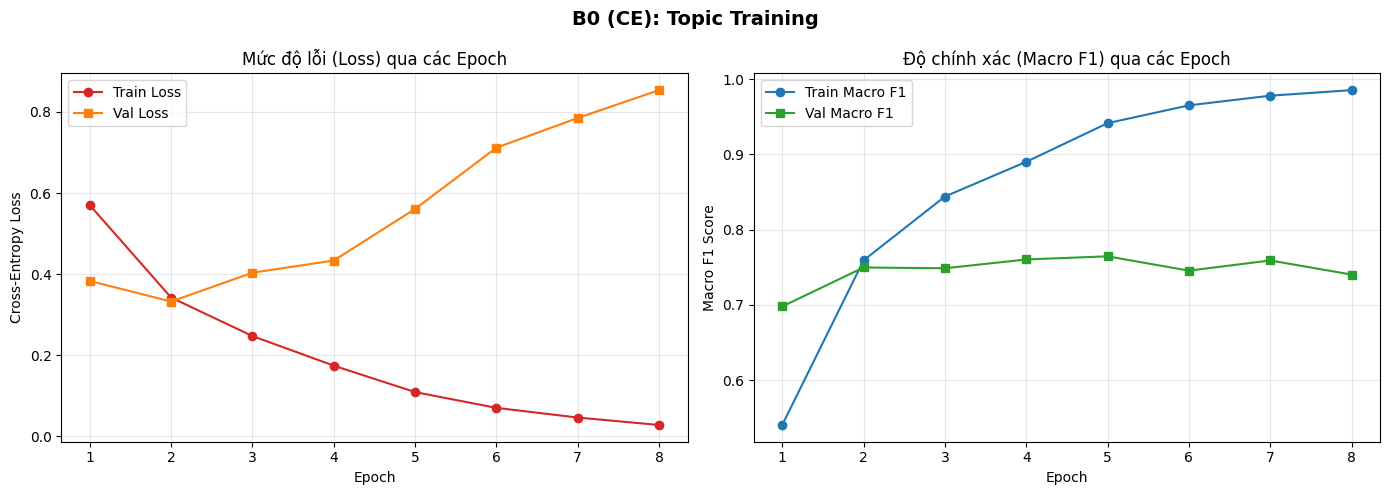


Chẩn đoán validation === B0_CE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9291    0.9331    0.9311      1151
    Training     0.7263    0.7453    0.7357       267
    Facility     0.9219    0.8429    0.8806        70
      Others     0.5281    0.4947    0.5109        95

    accuracy                         0.8711      1583
   macro avg     0.7763    0.7540    0.7646      1583
weighted avg     0.8705    0.8711    0.8707      1583


=== B0 (CE) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9205    0.9354    0.9279      2290
Training Program     0.7403    0.7028    0.7211       572
        Facility     0.9398    0.8621    0.8993       145
          Others     0.4908    0.5031    0.4969       159

        accuracy                         0.8683      3166
       macro avg     0.7729    0.7508    0.7613      3166
    weighted avg     0.8673    0.8683    0.8676      3166



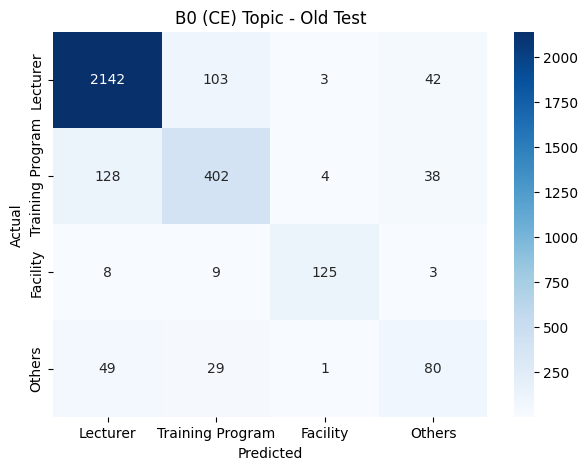


=== B0 (CE) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9355    0.9494    0.9424      2293
Training Program     0.8085    0.7428    0.7743       591
        Facility     0.9549    0.8699    0.9104       146
          Others     0.5153    0.6176    0.5619       136

        accuracy                         0.8929      3166
       macro avg     0.8036    0.7949    0.7972      3166
    weighted avg     0.8947    0.8929    0.8932      3166



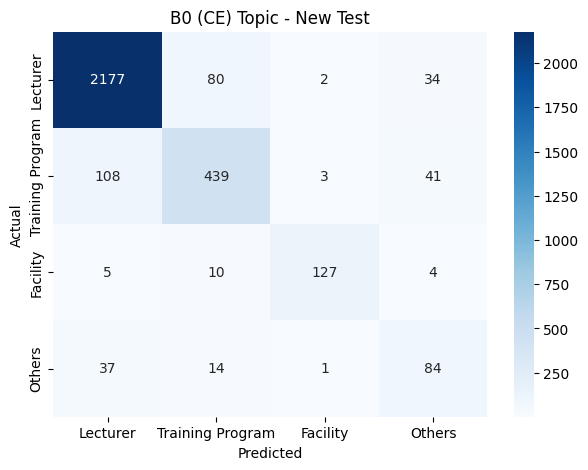


B0 (WCE): Single Task - Weighted Cross Entropy


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.7956 | Val Loss: 0.5812 | Train F1: 0.5656 | Val F1: 0.7337
New best (Val F1: 0.7337)
Epoch 02 | Train Loss: 0.5023 | Val Loss: 0.4709 | Train F1: 0.7402 | Val F1: 0.7115
Không cải thiện 1/3
Epoch 03 | Train Loss: 0.3285 | Val Loss: 0.6626 | Train F1: 0.8381 | Val F1: 0.8075
New best (Val F1: 0.8075)
Epoch 04 | Train Loss: 0.2073 | Val Loss: 0.9764 | Train F1: 0.9033 | Val F1: 0.8012
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.1194 | Val Loss: 1.4065 | Train F1: 0.9493 | Val F1: 0.8075
New best (Val F1: 0.8075)
Epoch 06 | Train Loss: 0.0662 | Val Loss: 1.6790 | Train F1: 0.9749 | Val F1: 0.8054
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0363 | Val Loss: 1.5682 | Train F1: 0.9862 | Val F1: 0.7909
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0226 | Val Loss: 1.8281 | Train F1: 0.9922 | Val F1: 0.7890
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.8075


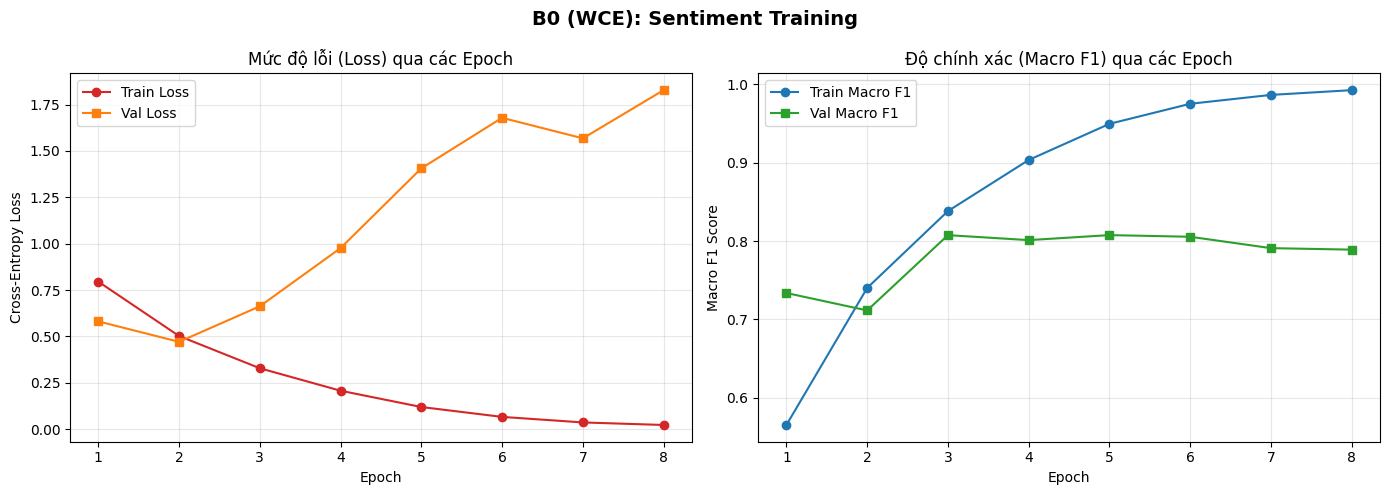


Chẩn đoán validation === B0_WCE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9318    0.9504    0.9410       705
     Neutral     0.6296    0.4658    0.5354        73
    Positive     0.9432    0.9491    0.9461       805

    accuracy                         0.9274      1583
   macro avg     0.8349    0.7884    0.8075      1583
weighted avg     0.9237    0.9274    0.9249      1583


=== B0 (WCE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9072    0.9510    0.9286      1409
     Neutral     0.5794    0.3713    0.4526       167
    Positive     0.9317    0.9270    0.9294      1590

    accuracy                         0.9084      3166
   macro avg     0.8061    0.7498    0.7702      3166
weighted avg     0.9023    0.9084    0.9039      3166



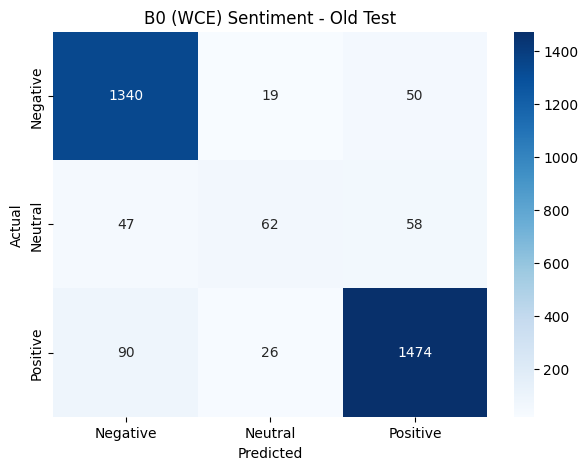


=== B0 (WCE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9127    0.9615    0.9364      1402
     Neutral     0.6075    0.4114    0.4906       158
    Positive     0.9513    0.9371    0.9442      1606

    accuracy                         0.9217      3166
   macro avg     0.8238    0.7700    0.7904      3166
weighted avg     0.9170    0.9217    0.9181      3166



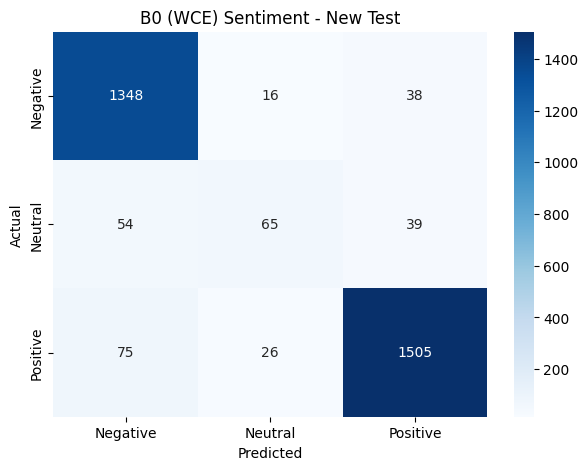

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.9679 | Val Loss: 0.7042 | Train F1: 0.4680 | Val F1: 0.6690
New best (Val F1: 0.6690)
Epoch 02 | Train Loss: 0.5427 | Val Loss: 0.5539 | Train F1: 0.7265 | Val F1: 0.7321
New best (Val F1: 0.7321)
Epoch 03 | Train Loss: 0.3728 | Val Loss: 0.5834 | Train F1: 0.8080 | Val F1: 0.7478
New best (Val F1: 0.7478)
Epoch 04 | Train Loss: 0.2430 | Val Loss: 0.8517 | Train F1: 0.8756 | Val F1: 0.7696
New best (Val F1: 0.7696)
Epoch 05 | Train Loss: 0.1598 | Val Loss: 1.0168 | Train F1: 0.9222 | Val F1: 0.7637
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0923 | Val Loss: 1.3191 | Train F1: 0.9551 | Val F1: 0.7584
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0580 | Val Loss: 1.6699 | Train F1: 0.9709 | Val F1: 0.7754
New best (Val F1: 0.7754)
Epoch 08 | Train Loss: 0.0371 | Val Loss: 1.6954 | Train F1: 0.9836 | Val F1: 0.7626
Không cải thiện 1/3
Epoch 09 | Train Loss: 0.0224 | Val Loss: 1.8681 | Train F1: 0.9890 | Val F1: 0.7716
Không cải thiện 2/3
Epoch 10 | Train Loss: 0.

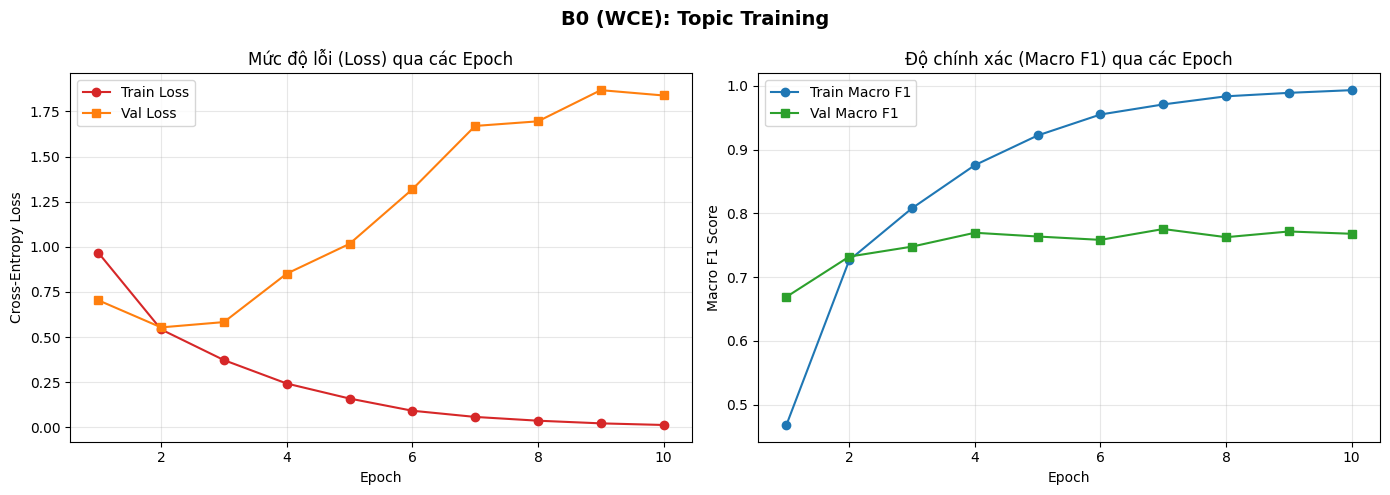


Chẩn đoán validation === B0_WCE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9224    0.9401    0.9312      1151
    Training     0.7519    0.7266    0.7390       267
    Facility     0.8986    0.8857    0.8921        70
      Others     0.5783    0.5053    0.5393        95

    accuracy                         0.8756      1583
   macro avg     0.7878    0.7644    0.7754      1583
weighted avg     0.8720    0.8756    0.8735      1583


=== B0 (WCE) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9327    0.9253    0.9290      2290
Training Program     0.7183    0.7535    0.7355       572
        Facility     0.8912    0.9034    0.8973       145
          Others     0.4966    0.4591    0.4771       159

        accuracy                         0.8699      3166
       macro avg     0.7597    0.7603    0.7597      3166
    weighted avg     0.8701    0.8699    0.8699      3166



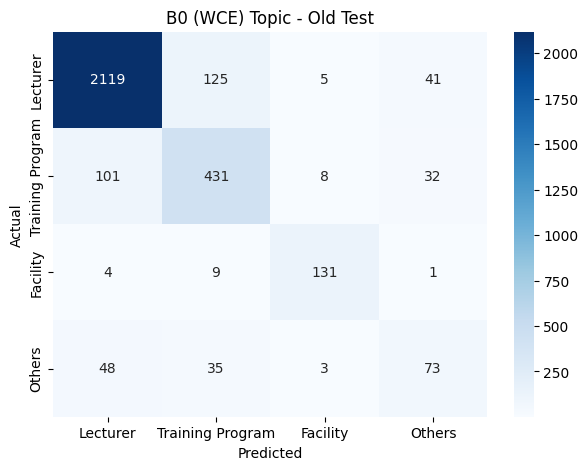


=== B0 (WCE) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9481    0.9394    0.9437      2293
Training Program     0.7800    0.7919    0.7859       591
        Facility     0.9048    0.9110    0.9078       146
          Others     0.5442    0.5882    0.5654       136

        accuracy                         0.8955      3166
       macro avg     0.7943    0.8076    0.8007      3166
    weighted avg     0.8973    0.8955    0.8963      3166



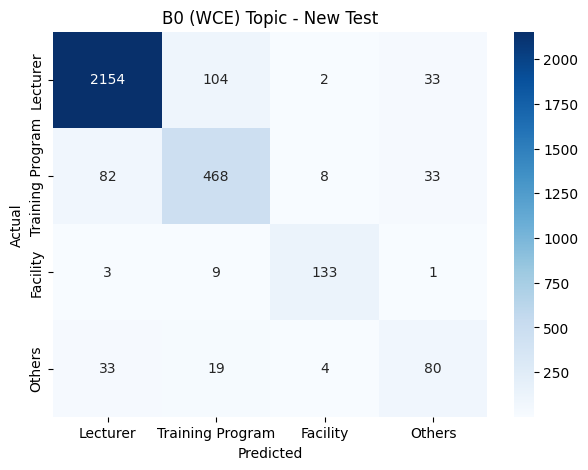


B0 (Focal): Single Task - Focal Loss


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.0377 | Val Loss: 0.0232 | Train F1: 0.5398 | Val F1: 0.7017
New best (Val F1: 0.7017)
Epoch 02 | Train Loss: 0.0215 | Val Loss: 0.0241 | Train F1: 0.6927 | Val F1: 0.7885
New best (Val F1: 0.7885)
Epoch 03 | Train Loss: 0.0136 | Val Loss: 0.0189 | Train F1: 0.7707 | Val F1: 0.7686
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.0080 | Val Loss: 0.0274 | Train F1: 0.8429 | Val F1: 0.7804
Không cải thiện 2/3
Epoch 05 | Train Loss: 0.0041 | Val Loss: 0.0501 | Train F1: 0.9106 | Val F1: 0.7956
New best (Val F1: 0.7956)
Epoch 06 | Train Loss: 0.0021 | Val Loss: 0.0703 | Train F1: 0.9532 | Val F1: 0.7864
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0012 | Val Loss: 0.0675 | Train F1: 0.9713 | Val F1: 0.7734
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0008 | Val Loss: 0.0891 | Train F1: 0.9820 | Val F1: 0.7869
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.7956


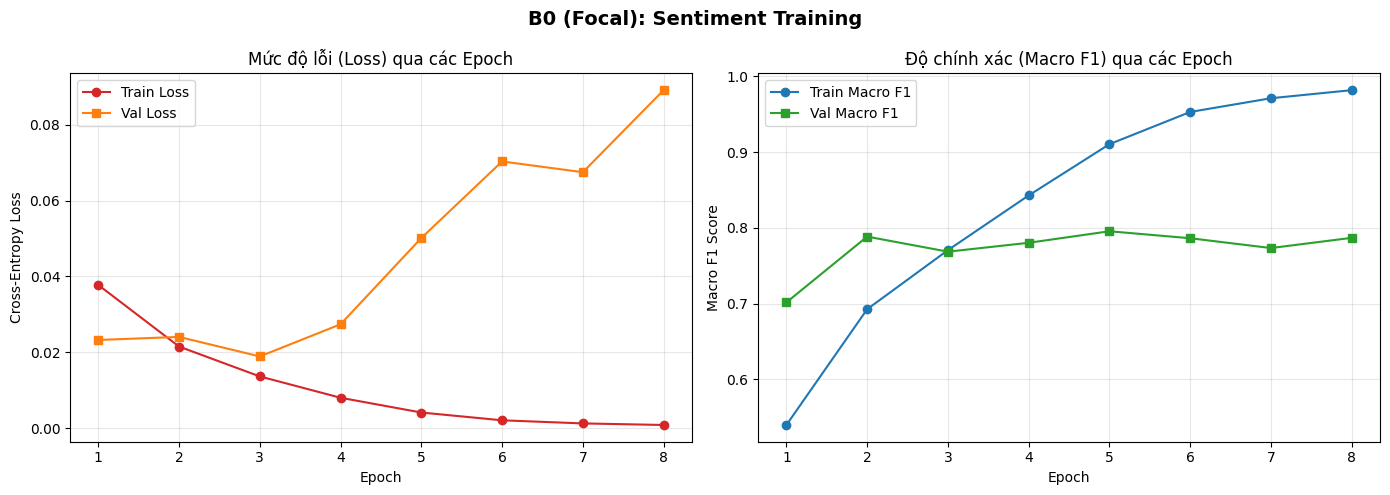


Chẩn đoán validation === B0_Focal_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9270    0.9362    0.9315       705
     Neutral     0.4713    0.5616    0.5125        73
    Positive     0.9554    0.9304    0.9427       805

    accuracy                         0.9160      1583
   macro avg     0.7845    0.8094    0.7956      1583
weighted avg     0.9204    0.9160    0.9179      1583


=== B0 (FOCAL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9019    0.9397    0.9204      1409
     Neutral     0.4340    0.4132    0.4233       167
    Positive     0.9409    0.9107    0.9255      1590

    accuracy                         0.8973      3166
   macro avg     0.7589    0.7545    0.7564      3166
weighted avg     0.8968    0.8973    0.8968      3166



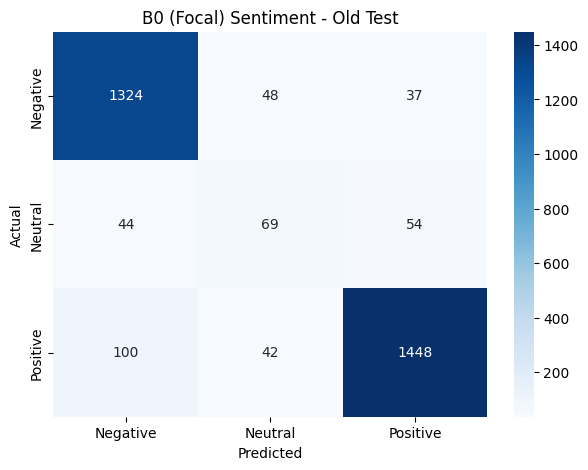


=== B0 (FOCAL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9074    0.9501    0.9282      1402
     Neutral     0.4340    0.4367    0.4353       158
    Positive     0.9578    0.9178    0.9374      1606

    accuracy                         0.9081      3166
   macro avg     0.7664    0.7682    0.7670      3166
weighted avg     0.9093    0.9081    0.9083      3166



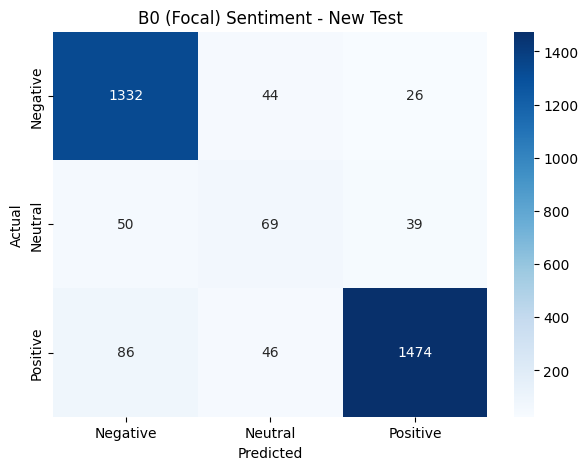

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.0335 | Val Loss: 0.0185 | Train F1: 0.4394 | Val F1: 0.6440
New best (Val F1: 0.6440)
Epoch 02 | Train Loss: 0.0165 | Val Loss: 0.0195 | Train F1: 0.6721 | Val F1: 0.7204
New best (Val F1: 0.7204)
Epoch 03 | Train Loss: 0.0104 | Val Loss: 0.0247 | Train F1: 0.7385 | Val F1: 0.7248
New best (Val F1: 0.7248)
Epoch 04 | Train Loss: 0.0062 | Val Loss: 0.0216 | Train F1: 0.8066 | Val F1: 0.7293
New best (Val F1: 0.7293)
Epoch 05 | Train Loss: 0.0038 | Val Loss: 0.0290 | Train F1: 0.8518 | Val F1: 0.7397
New best (Val F1: 0.7397)
Epoch 06 | Train Loss: 0.0027 | Val Loss: 0.0366 | Train F1: 0.8783 | Val F1: 0.7473
New best (Val F1: 0.7473)
Epoch 07 | Train Loss: 0.0015 | Val Loss: 0.0502 | Train F1: 0.9220 | Val F1: 0.7421
Không cải thiện 1/3
Epoch 08 | Train Loss: 0.0011 | Val Loss: 0.0547 | Train F1: 0.9376 | Val F1: 0.7674
New best (Val F1: 0.7674)
Epoch 09 | Train Loss: 0.0009 | Val Loss: 0.0520 | Train F1: 0.9442 | Val F1: 0.7508
Không cải thiện 1/3
Epoch 10 | Tr

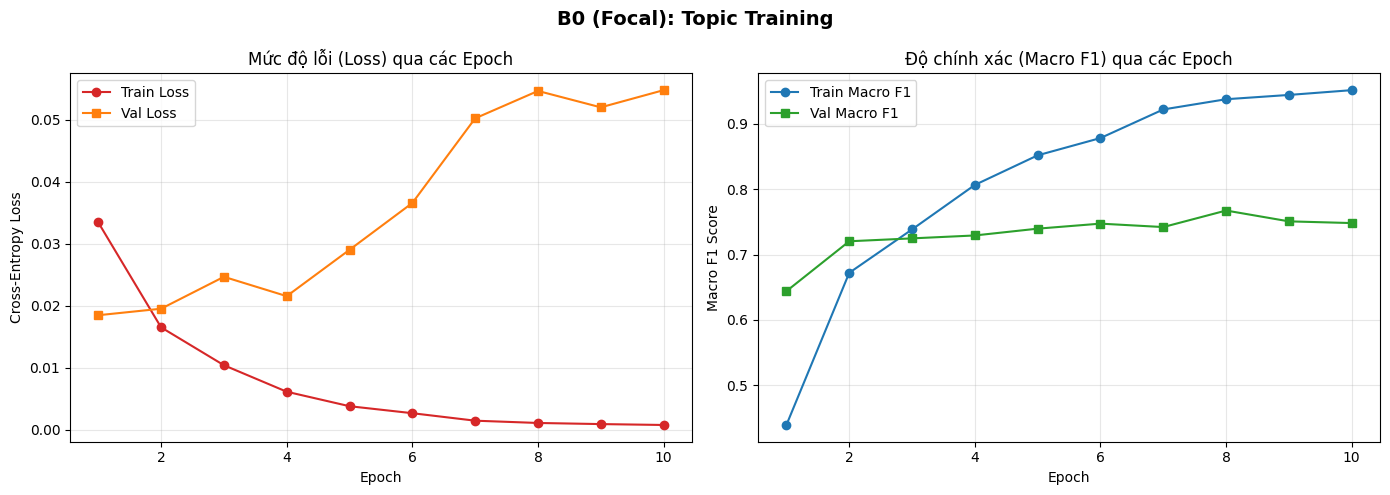


Chẩn đoán validation === B0_Focal_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9345    0.9175    0.9259      1151
    Training     0.6987    0.7903    0.7417       267
    Facility     0.8611    0.8857    0.8732        70
      Others     0.5823    0.4842    0.5287        95

    accuracy                         0.8686      1583
   macro avg     0.7691    0.7694    0.7674      1583
weighted avg     0.8704    0.8686    0.8687      1583


=== B0 (FOCAL) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9423    0.9061    0.9239      2290
Training Program     0.6884    0.7920    0.7366       572
        Facility     0.8784    0.8966    0.8874       145
          Others     0.4937    0.4906    0.4921       159

        accuracy                         0.8642      3166
       macro avg     0.7507    0.7713    0.7600      3166
    weighted avg     0.8710    0.8642    0.8667      3166



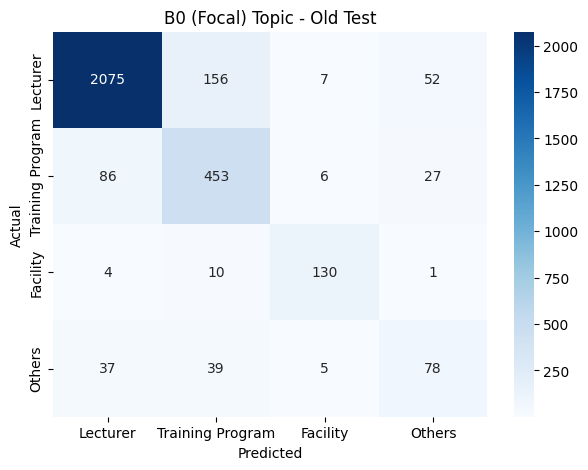


=== B0 (FOCAL) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9591    0.9211    0.9397      2293
Training Program     0.7584    0.8443    0.7990       591
        Facility     0.8919    0.9041    0.8980       146
          Others     0.5063    0.5882    0.5442       136

        accuracy                         0.8917      3166
       macro avg     0.7789    0.8144    0.7952      3166
    weighted avg     0.8991    0.8917    0.8945      3166



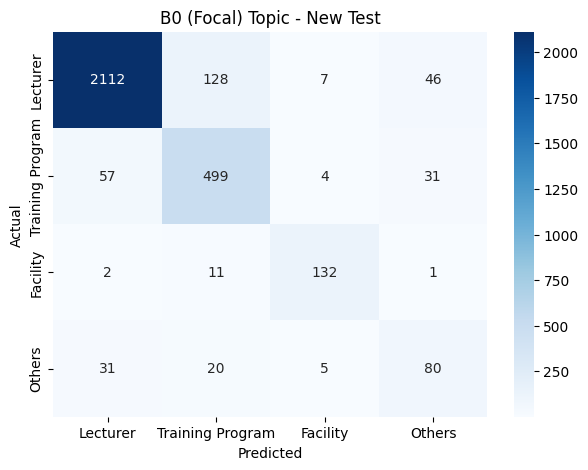


B0 (ASL): Single Task - Asymmetric Loss


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.4696 | Val Loss: 0.2848 | Train F1: 0.5940 | Val F1: 0.6847
New best (Val F1: 0.6847)
Epoch 02 | Train Loss: 0.2191 | Val Loss: 0.2072 | Train F1: 0.7551 | Val F1: 0.7927
New best (Val F1: 0.7927)
Epoch 03 | Train Loss: 0.1439 | Val Loss: 0.2284 | Train F1: 0.8200 | Val F1: 0.7642
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.0913 | Val Loss: 0.2317 | Train F1: 0.8681 | Val F1: 0.8052
New best (Val F1: 0.8052)
Epoch 05 | Train Loss: 0.0687 | Val Loss: 0.2497 | Train F1: 0.9081 | Val F1: 0.7995
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0440 | Val Loss: 0.2941 | Train F1: 0.9479 | Val F1: 0.7945
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0306 | Val Loss: 0.3346 | Train F1: 0.9649 | Val F1: 0.7864
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation sentiment Macro F1: 0.8052


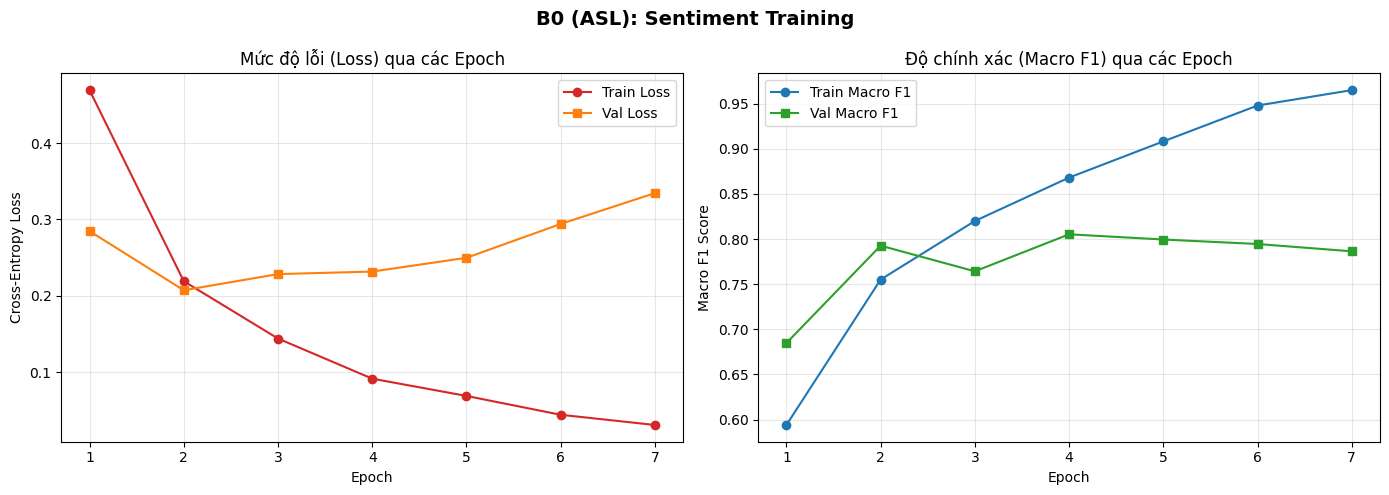


Chẩn đoán validation === B0_ASL_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9362    0.9574    0.9467       705
     Neutral     0.6400    0.4384    0.5203        73
    Positive     0.9446    0.9528    0.9487       805

    accuracy                         0.9311      1583
   macro avg     0.8403    0.7829    0.8052      1583
weighted avg     0.9268    0.9311    0.9280      1583


=== B0 (ASL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9163    0.9326    0.9244      1409
     Neutral     0.5263    0.3593    0.4270       167
    Positive     0.9190    0.9352    0.9271      1590

    accuracy                         0.9037      3166
   macro avg     0.7872    0.7424    0.7595      3166
weighted avg     0.8971    0.9037    0.8995      3166



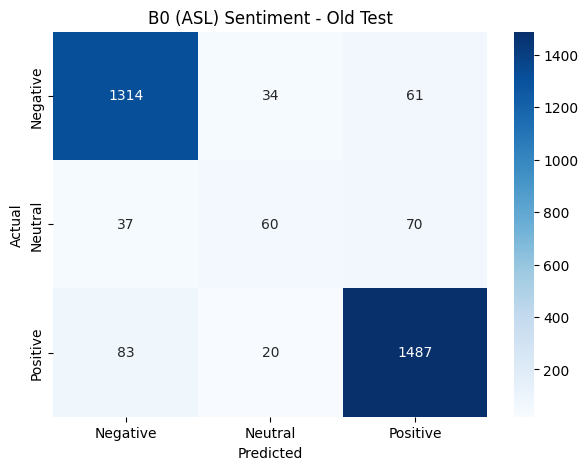


=== B0 (ASL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9219    0.9429    0.9323      1402
     Neutral     0.5614    0.4051    0.4706       158
    Positive     0.9382    0.9452    0.9417      1606

    accuracy                         0.9172      3166
   macro avg     0.8072    0.7644    0.7815      3166
weighted avg     0.9122    0.9172    0.9140      3166



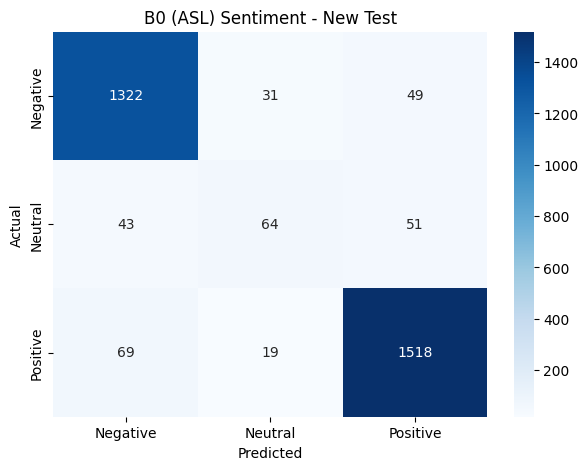

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 0.5235 | Val Loss: 0.3031 | Train F1: 0.5370 | Val F1: 0.7264
New best (Val F1: 0.7264)
Epoch 02 | Train Loss: 0.2977 | Val Loss: 0.3012 | Train F1: 0.7426 | Val F1: 0.7718
New best (Val F1: 0.7718)
Epoch 03 | Train Loss: 0.2203 | Val Loss: 0.3169 | Train F1: 0.8056 | Val F1: 0.7475
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.1571 | Val Loss: 0.3659 | Train F1: 0.8581 | Val F1: 0.7701
Không cải thiện 2/3
Epoch 05 | Train Loss: 0.1059 | Val Loss: 0.4069 | Train F1: 0.9061 | Val F1: 0.7561
Không cải thiện 3/3
Early stopping tại epoch 5!

Best validation topic Macro F1: 0.7718


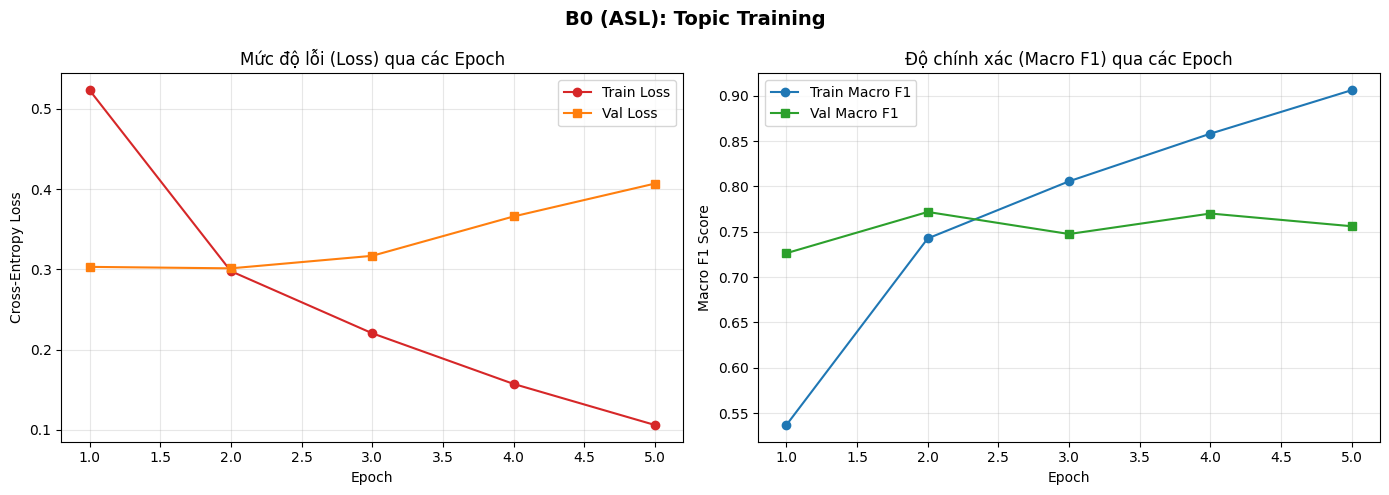


Chẩn đoán validation === B0_ASL_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9469    0.9296    0.9382      1151
    Training     0.7640    0.7640    0.7640       267
    Facility     0.8133    0.8714    0.8414        70
      Others     0.5045    0.5895    0.5437        95

    accuracy                         0.8787      1583
   macro avg     0.7572    0.7886    0.7718      1583
weighted avg     0.8836    0.8787    0.8809      1583


=== B0 (ASL) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9403    0.9218    0.9310      2290
Training Program     0.7398    0.7255    0.7326       572
        Facility     0.8767    0.8828    0.8797       145
          Others     0.4206    0.5660    0.4826       159

        accuracy                         0.8667      3166
       macro avg     0.7443    0.7740    0.7565      3166
    weighted avg     0.8751    0.8667    0.8703      3166



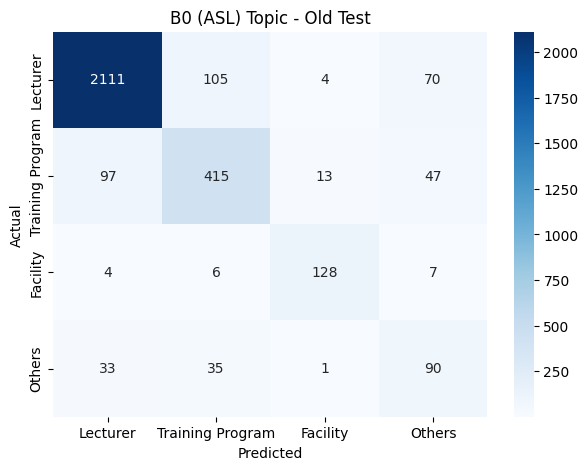


=== B0 (ASL) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9586    0.9385    0.9484      2293
Training Program     0.8075    0.7665    0.7865       591
        Facility     0.8904    0.8904    0.8904       146
          Others     0.4533    0.7132    0.5543       136

        accuracy                         0.8945      3166
       macro avg     0.7774    0.8272    0.7949      3166
    weighted avg     0.9055    0.8945    0.8986      3166



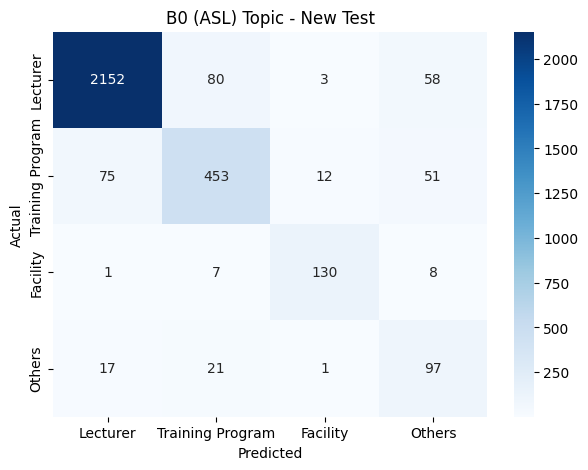

In [ ]:
class BaselineModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

def train_single_task(model, train_loader, val_loader, loss_fn, task, model_name="b0", patience=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: HUẤN LUYỆN (TRAINING)
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        
        for batch in train_loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            targets = batch[task].to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss = loss_fn(logits, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            train_preds.extend(logits.argmax(-1).cpu().tolist())
            train_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Train
        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")

        # PHA 2: KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets = batch[task].to(DEVICE) # <-- Cần lấy targets để tính val_loss
                
                logits = model(ids, mask)
                loss = loss_fn(logits, targets)
                
                val_loss += loss.item()
                val_preds.extend(logits.argmax(-1).cpu().tolist())
                val_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Validation
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        
        # PHA 3: LƯU LỊCH SỬ VÀ IN KẾT QUẢ
        history.append({
            "epoch": epoch, 
            "train_loss": train_loss, "val_loss": val_loss,
            # "train_acc": train_acc, "val_acc": val_acc,
            "train_f1": train_f1, "val_f1": val_f1
        })
        
        # Format chuỗi in ra y hệt yêu cầu của bạn
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

        # Early Stopping dựa trên Val F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Val F1: {best_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    # Load lại weights tốt nhất trước khi trả về
    model.load_state_dict(best_state)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest validation {task} Macro F1: {best_f1:.4f}")
    
    return model, pd.DataFrame(history), best_f1


# Khởi tạo các hàm loss
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)

# CHẠY THỰC NGHIỆM B0 - SINGLE TASK LEARNING (ĐỘC LẬP TỪNG TASK)
results_old_test_stl = {}
results_new_test_stl = {}

# HÀM BỔ TRỢ: Lấy F1 Macro từ Dictionary Report để nhét vào bảng
def get_macro_f1_from_report(report_dict):
    return report_dict["macro avg"]["f1-score"]


# ── 1. B0 (CE): Standard Cross Entropy ──
print("\n" + "="*50)
print("B0 (CE): Single Task - Standard Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_ce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_ce_sent, hist_b0_ce_sent, _ = train_single_task(model_b0_ce_sent, train_loader, val_loader, 
                                                         ce_sent, task="sentiment", model_name="B0_CE_Sent")
plot_training_history(hist_b0_ce_sent, title="B0 (CE): Sentiment Training")
diagnose_validation_single_task(model_b0_ce_sent, val_loader, "B0_CE_Sent", task="sentiment")
rep_sent_old_ce = evaluate_and_plot(model_b0_ce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - Old Test")
rep_sent_new_ce = evaluate_and_plot(model_b0_ce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - New Test")

# >> Topic
model_b0_ce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_ce_topic, hist_b0_ce_topic, _ = train_single_task(model_b0_ce_topic, train_loader, val_loader, 
                                                           ce_topic, task="topic", model_name="B0_CE_Topic")
plot_training_history(hist_b0_ce_topic, title="B0 (CE): Topic Training")
diagnose_validation_single_task(model_b0_ce_topic, val_loader, "B0_CE_Topic", task="topic")
rep_topic_old_ce = evaluate_and_plot(model_b0_ce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (CE) Topic - Old Test")
rep_topic_new_ce = evaluate_and_plot(model_b0_ce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (CE) Topic - New Test")

# >> Đóng gói kết quả (Giả lập cấu trúc MTL để in bảng)
results_old_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_ce),
    "sent_report": rep_sent_old_ce,
    "topic_report": rep_topic_old_ce
}
results_new_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_ce),
    "sent_report": rep_sent_new_ce,
    "topic_report": rep_topic_new_ce
}


# ── 2. B0 (WCE): Weighted Cross Entropy ──
print("\n" + "="*50)
print("B0 (WCE): Single Task - Weighted Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_wce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_wce_sent, hist_b0_wce_sent, _ = train_single_task(model_b0_wce_sent, train_loader, val_loader, 
                                                           wce_sent, task="sentiment", model_name="B0_WCE_Sent")
plot_training_history(hist_b0_wce_sent, title="B0 (WCE): Sentiment Training")
diagnose_validation_single_task(model_b0_wce_sent, val_loader, "B0_WCE_Sent", task="sentiment")
rep_sent_old_wce = evaluate_and_plot(model_b0_wce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - Old Test")
rep_sent_new_wce = evaluate_and_plot(model_b0_wce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - New Test")

# >> Topic
model_b0_wce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_wce_topic, hist_b0_wce_topic, _ = train_single_task(model_b0_wce_topic, train_loader, val_loader, 
                                                             wce_topic, task="topic", model_name="B0_WCE_Topic")
plot_training_history(hist_b0_wce_topic, title="B0 (WCE): Topic Training")
diagnose_validation_single_task(model_b0_wce_topic, val_loader, "B0_WCE_Topic", task="topic")
rep_topic_old_wce = evaluate_and_plot(model_b0_wce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (WCE) Topic - Old Test")
rep_topic_new_wce = evaluate_and_plot(model_b0_wce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (WCE) Topic - New Test")

results_old_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_wce),
    "sent_report": rep_sent_old_wce,
    "topic_report": rep_topic_old_wce
}
results_new_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_wce),
    "sent_report": rep_sent_new_wce,
    "topic_report": rep_topic_new_wce
}


# ── 3. B0 (Focal): Focal Loss ──
print("\n" + "="*50)
print("B0 (Focal): Single Task - Focal Loss")
print("="*50)
# >> Sentiment
model_b0_focal_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_focal_sent, hist_b0_focal_sent, _ = train_single_task(model_b0_focal_sent, train_loader, val_loader, 
                                                               focal_sent, task="sentiment", model_name="B0_Focal_Sent")
plot_training_history(hist_b0_focal_sent, title="B0 (Focal): Sentiment Training")
diagnose_validation_single_task(model_b0_focal_sent, val_loader, "B0_Focal_Sent", task="sentiment")
rep_sent_old_focal = evaluate_and_plot(model_b0_focal_sent, test_loader, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - Old Test")
rep_sent_new_focal = evaluate_and_plot(model_b0_focal_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - New Test")

# >> Topic
model_b0_focal_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_focal_topic, hist_b0_focal_topic, _ = train_single_task(model_b0_focal_topic, train_loader, val_loader, 
                                                                 focal_topic, task="topic", model_name="B0_Focal_Topic")
plot_training_history(hist_b0_focal_topic, title="B0 (Focal): Topic Training")
diagnose_validation_single_task(model_b0_focal_topic, val_loader, "B0_Focal_Topic", task="topic")
rep_topic_old_focal = evaluate_and_plot(model_b0_focal_topic, test_loader, "topic", TOPIC_NAMES, "B0 (Focal) Topic - Old Test")
rep_topic_new_focal = evaluate_and_plot(model_b0_focal_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (Focal) Topic - New Test")

results_old_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_focal),
    "sent_report": rep_sent_old_focal,
    "topic_report": rep_topic_old_focal
}
results_new_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_focal),
    "sent_report": rep_sent_new_focal,
    "topic_report": rep_topic_new_focal
}


# ── 4. B0 (ASL): Asymmetric Loss ──
print("\n" + "="*50)
print("B0 (ASL): Single Task - Asymmetric Loss")
print("="*50)
# >> Sentiment
model_b0_asl_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_asl_sent, hist_b0_asl_sent, _ = train_single_task(model_b0_asl_sent, train_loader, val_loader, 
                                                           asl_sent, task="sentiment", model_name="B0_ASL_Sent")
plot_training_history(hist_b0_asl_sent, title="B0 (ASL): Sentiment Training")
diagnose_validation_single_task(model_b0_asl_sent, val_loader, "B0_ASL_Sent", task="sentiment")
rep_sent_old_asl = evaluate_and_plot(model_b0_asl_sent, test_loader, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - Old Test")
rep_sent_new_asl = evaluate_and_plot(model_b0_asl_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - New Test")

# >> Topic
model_b0_asl_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_asl_topic, hist_b0_asl_topic, _ = train_single_task(model_b0_asl_topic, train_loader, val_loader, 
                                                             asl_topic, task="topic", model_name="B0_ASL_Topic")
plot_training_history(hist_b0_asl_topic, title="B0 (ASL): Topic Training")
diagnose_validation_single_task(model_b0_asl_topic, val_loader, "B0_ASL_Topic", task="topic")
rep_topic_old_asl = evaluate_and_plot(model_b0_asl_topic, test_loader, "topic", TOPIC_NAMES, "B0 (ASL) Topic - Old Test")
rep_topic_new_asl = evaluate_and_plot(model_b0_asl_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (ASL) Topic - New Test")

results_old_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_asl),
    "sent_report": rep_sent_old_asl,
    "topic_report": rep_topic_old_asl
}
results_new_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_asl),
    "sent_report": rep_sent_new_asl,
    "topic_report": rep_topic_new_asl
}